Speed ratio nu = 1.200, VT = 300.0 m/s, VP = 360.0 m/s
Initial geometry: xT0 = 4000.0 m, yP0 = 1500.0 m
Minimum Rmiss over sweep = 0.078954 m at alpha_P = -0.061820 rad (-3.542 deg)
Time of closest approach at that alpha = 67.440081 s


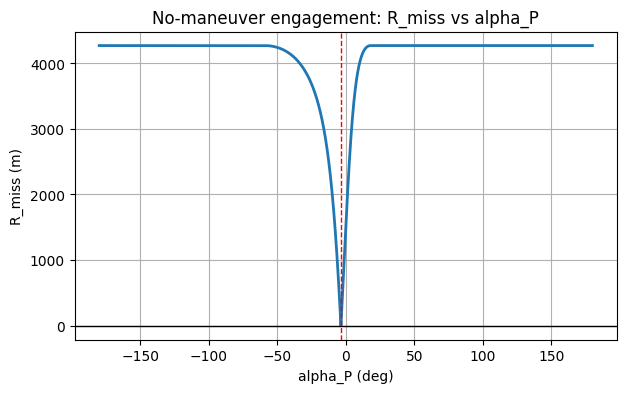

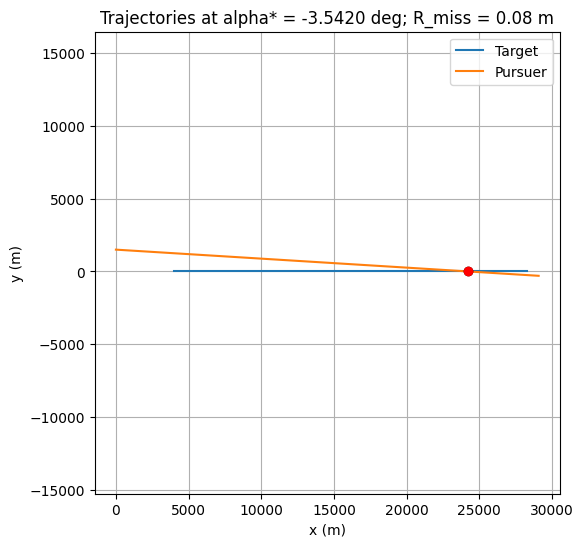

In [1]:

import numpy as np
import matplotlib.pyplot as plt


VT = 300.0           
nu = 1.2            
VP = nu * VT        
xT0 = 4000.0          
yP0 = 1500.0          
alphas = np.linspace(-np.pi, np.pi, 360001)  


x0, y0 = xT0, -yP0

def miss_distance_and_tca(a):
    vx = VT - VP*np.cos(a)
    vy = - VP*np.sin(a)
    v2 = vx*vx + vy*vy
    
    if v2 < 1e-12:
        return np.hypot(x0, y0), np.nan
    t_ca = - (x0*vx + y0*vy) / v2   
   
    t_eval = max(0.0, t_ca)
    Rmiss = np.hypot(x0 + vx*t_eval, y0 + vy*t_eval)
    return Rmiss, t_eval

Rmiss_list, tca_list = [], []
for a in alphas:
    Rmiss, tca = miss_distance_and_tca(a)
    Rmiss_list.append(Rmiss)
    tca_list.append(tca)

Rmiss_arr = np.array(Rmiss_list)
tca_arr = np.array(tca_list)


idx_min = np.argmin(Rmiss_arr)
alpha_star = alphas[idx_min]
Rmin = Rmiss_arr[idx_min]
t_star = tca_arr[idx_min]

print(f"Speed ratio nu = {nu:.3f}, VT = {VT:.1f} m/s, VP = {VP:.1f} m/s")
print(f"Initial geometry: xT0 = {xT0:.1f} m, yP0 = {yP0:.1f} m")
print(f"Minimum Rmiss over sweep = {Rmin:.6f} m at alpha_P = {alpha_star:.6f} rad ({np.degrees(alpha_star):.3f} deg)")
print(f"Time of closest approach at that alpha = {t_star:.6f} s")

# Plot Rmiss vs alpha_P
plt.figure(figsize=(7,4))
plt.plot(np.degrees(alphas), Rmiss_arr, lw=2)
plt.axhline(0, color='k', lw=1)
plt.axvline(np.degrees(alpha_star), color='r', ls='--', lw=1)
plt.xlabel("alpha_P (deg)")
plt.ylabel("R_miss (m)")
plt.title("No‑maneuver engagement: R_miss vs alpha_P")
plt.grid(True)
plt.show()


a = alpha_star
vx = VT - VP*np.cos(a); vy = -VP*np.sin(a)
tmax = max(15.0, 1.2*max(1e-6, t_star))
ts = np.linspace(0, tmax, 600)

xT = xT0 + VT*ts
yT = np.zeros_like(ts)

xP = 0 + VP*np.cos(a)*ts
yP = yP0 + VP*np.sin(a)*ts

plt.figure(figsize=(6,6))
plt.plot(xT, yT, label="Target")
plt.plot(xP, yP, label="Pursuer")
# closest-approach points
xT_ca = xT0 + VT*t_star
yT_ca = 0.0
xP_ca = VP*np.cos(a)*t_star
yP_ca = yP0 + VP*np.sin(a)*t_star
plt.plot([xT_ca], [yT_ca], 'ko')
plt.plot([xP_ca], [yP_ca], 'ro')
plt.legend()
plt.axis('equal'); plt.grid(True)
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.title(f"Trajectories at alpha* = {np.degrees(a):.4f} deg; R_miss = {Rmin:.2f} m")
plt.show()